In [6]:
!apt-get update
!apt-get install sagemath
!pip install cysignals
from sage.all import *
import z3

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,177 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,254 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.8 MB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,669 kB]
Get:14 http://security.u

ModuleNotFoundError: No module named 'cysignals.signals'

## Individual Best Response Graphs for two-player, two-action games and a one-period memory

Companion code for Part II of the lecture on basins of attraction in multiagent reinforcement learning of the Summer School on Modern Methods in Reinforcement Learning.

In [1]:
def make_strats(n=4):
    return [
        list(Integer(i).digits(base=2, padto=n))[::-1]
        for i in range(2^n)
    ]


def from_binary_digits(bits):
    z = ZZ(0)
    for b in bits:
        z = 2*z + ZZ(b)
    return z


def sage_condition_to_z3(cond, env):
    """
    Convert a Sage symbolic inequality into a Z3 Boolean expression. This uses string conversion.
    For expressions produced by this model,this is usually reliable because the expressions involve
    only rational operations, variables, and inequalities.
    """
    s = str(cond)
    s = s.replace("^", "**")
    return eval(s, {"__builtins__": {}}, env)


def z3_environment():
    import z3

    names = [
        "delta", "epsilon", "t", "r", "p", "s",
        "q111", "q112", "q121", "q122",
        "q131", "q132", "q141", "q142"
    ]

    env = {name: z3.Real(name) for name in names}
    env["And"] = z3.And
    env["Or"] = z3.Or
    env["Not"] = z3.Not
    env["If"] = z3.If
    return env

def payoff_domain_conditions(delta, epsilon, t, r, p, s, game="PD"):
    """
    Return domain conditions for different payoff orderings.

    game options:
        "PD"      Prisoner's dilemma: t > r > p > s
        "SH"      Stag hunt:           r > t > p > s
        "SD"      Snowdrift:           t > r > s > p
        "custom"  only imposes delta and epsilon restrictions
    """

    base_conditions = [
        delta > 0,
        delta < 1,
        epsilon > 0,
        epsilon < 1,
    ]

    if game == "PD":
        payoff_conditions = [
            t > r,
            r > p,
            p > s,
        ]

    elif game == "SH":
        payoff_conditions = [
            r > t,
            t > p,
            p > s,
        ]

    elif game == "SD":
        payoff_conditions = [
            t > r,
            r > s,
            s > p,
        ]

    elif game == "custom":
        payoff_conditions = []

    else:
        raise ValueError("Unknown game type. Use 'PD', 'SH', 'SD', or 'custom'.")

    return base_conditions + payoff_conditions


def z3_feasible(conditions, timeout_ms=10000):
    """
    Return True if the list of Sage inequalities is jointly feasible.
    """
    import z3

    env = z3_environment()
    solver = z3.Solver()
    solver.set("timeout", int(timeout_ms))

    for c in conditions:
        solver.add(sage_condition_to_z3(c, env))

    ans = solver.check()

    if ans == z3.sat:
        return True
    elif ans == z3.unsat:
        return False
    else:
        return None


def z3_valid_under_domain(domain_conditions, target_conditions, timeout_ms=10000):
    """
    Check whether domain_conditions => target_conditions is valid. Equivalently, check whether
    domain_conditions && not(target_conditions) is infeasible.
    """
    import z3

    env = z3_environment()
    solver = z3.Solver()
    solver.set("timeout", int(timeout_ms))

    domain_z3 = [
        sage_condition_to_z3(c, env)
        for c in domain_conditions
    ]

    target_z3 = [
        sage_condition_to_z3(c, env)
        for c in target_conditions
    ]

    solver.add(z3.And(*domain_z3))

    if len(target_z3) == 0:
        solver.add(z3.Not(True))
    else:
        solver.add(z3.Not(z3.And(*target_z3)))

    ans = solver.check()

    if ans == z3.unsat:
        return True
    elif ans == z3.sat:
        return False
    else:
        return None


def result(input_strategy, strats, game="PD", extra_domain_conditions=None, timeout_ms=10000):
    """
    Output format:

        [(input_index, strategy_index), True]

    if the best-response relation holds throughout the admissible domain, or

        [(input_index, strategy_index), conditions]

    if it holds only under the listed additional symbolic conditions.

    The argument game controls the payoff ordering:
        "PD"      t > r > p > s
        "SH"      r > t > p > s
        "SD"      t > r > s > p
        "custom"  no payoff ordering imposed

    Additional assumptions can be supplied through extra_domain_conditions.
    """

    delta, epsilon, t, r, p, s = var("delta epsilon t r p s")

    q = {}
    qvars = []

    for state in range(1, 5):
        for action in range(1, 3):
            name = "q1{}{}".format(state, action)
            q[(state, action)] = SR.var(name)
            qvars.append(q[(state, action)])

    output = []

    input_index = from_binary_digits(input_strategy) + 1

    input_bit_for_state = {
        1: 0,
        2: 2,
        3: 1,
        4: 3,
    }

    def opponent_gt(state):
        bit = input_strategy[input_bit_for_state[state]]
        return bit == 0

    def continuation_value(next_state, strat):
        qa = q[(next_state, 1)]
        qb = q[(next_state, 2)]

        if strat[next_state - 1] == 0:
            return (1 - epsilon/2)*qa + (epsilon/2)*qb
        else:
            return (epsilon/2)*qa + (1 - epsilon/2)*qb

    def noisy_choice(opp_gt, value_if_gt, value_if_lt):
        if opp_gt:
            return (1 - epsilon/2)*value_if_gt + (epsilon/2)*value_if_lt
        else:
            return (1 - epsilon/2)*value_if_lt + (epsilon/2)*value_if_gt

    domain_conditions = payoff_domain_conditions(
        delta, epsilon, t, r, p, s, game=game
    )

    if extra_domain_conditions is not None:
        domain_conditions += extra_domain_conditions(delta, epsilon, t, r, p, s)

    # The rest of the original function remains unchanged.

    for j, strat in enumerate(strats, start=1):

        equations = []

        for state in range(1, 5):

            ogt = opponent_gt(state)

            rhs_action_1 = noisy_choice(
                ogt,
                p + delta*continuation_value(1, strat),
                t + delta*continuation_value(2, strat)
            )

            equations.append(q[(state, 1)] == rhs_action_1)

            rhs_action_2 = noisy_choice(
                ogt,
                s + delta*continuation_value(3, strat),
                r + delta*continuation_value(4, strat)
            )

            equations.append(q[(state, 2)] == rhs_action_2)

        solns = solve(equations, qvars, solution_dict=True)

        if len(solns) == 0:
            continue

        sol = solns[0]

        consistency_conditions = []

        for state in range(1, 5):

            diff = (
                sol[q[(state, 1)]] - sol[q[(state, 2)]]
            ).simplify_full()

            if strat[state - 1] == 0:
                consistency_conditions.append(diff > 0)
            else:
                consistency_conditions.append(diff < 0)

        full_conditions = domain_conditions + consistency_conditions

        feasible = z3_feasible(full_conditions, timeout_ms=timeout_ms)

        if feasible is False:
            # Conditions cannot hold simultaneously.
            # This is the case you expected for most strategies.
            continue

        valid_everywhere = z3_valid_under_domain(
            domain_conditions,
            consistency_conditions,
            timeout_ms=timeout_ms
        )

        if valid_everywhere is True:
            output.append([
                (input_index, j),
                True
            ])
        elif feasible is True:
            output.append([
                (input_index, j),
                consistency_conditions
            ])
        else:
            output.append([
                (input_index, j),
                "Z3 returned unknown",
                consistency_conditions
            ])

    return output

def all_best_response_relations(strats, game="PD", extra_domain_conditions=None, timeout_ms=10000):
    """
    Compute possible best-response relations for all input strategies.

    For each input strategy i in strats, this calls

        result(i, strats)

    and collects all feasible best-response relations.

    Output format:
        [
            [(1, 1), True],
            [(2, 3), conditions],
            ...
        ]

    where the first coordinate is the input-strategy index and the second coordinate is
    the best-response strategy index.
    """

    all_output = []

    for input_strategy in strats:
        out = result(
        input_strategy,
        strats,
        game=game,
        extra_domain_conditions=extra_domain_conditions,
        timeout_ms=timeout_ms)

        for item in out:
            all_output.append(item)

    return all_output

In [ ]:
# This block does the same as the previous block but simplifies the resulting algebraic expression further. It does take longer to compute.

from sage.all import *
import operator


# -----------------------------------------------------------------------------
# Strategy utilities
# -----------------------------------------------------------------------------

def make_strats(n=4):
    return [
        list(Integer(i).digits(base=2, padto=n))[::-1]
        for i in range(2**n)
    ]


def from_binary_digits(bits):
    z = ZZ(0)
    for b in bits:
        z = 2*z + ZZ(b)
    return z


# -----------------------------------------------------------------------------
# Z3 conversion and implication checking
# -----------------------------------------------------------------------------

def z3_environment():
    import z3

    names = [
        "delta", "epsilon", "t", "r", "p", "s",
        "q111", "q112", "q121", "q122",
        "q131", "q132", "q141", "q142"
    ]

    env = {name: z3.Real(name) for name in names}
    env["And"] = z3.And
    env["Or"] = z3.Or
    env["Not"] = z3.Not
    env["If"] = z3.If
    return env


def sage_condition_to_z3(cond, env):
    """
    Convert a Sage symbolic relation into a Z3 Boolean expression.

    This intentionally keeps the original string-based approach, because the
    Bellman expressions produced here are rational expressions in a fixed set of
    real variables. The simplification layer below is conservative and uses Z3
    only to prove implications before removing conditions.
    """
    s = str(cond)
    s = s.replace("^", "**")
    return eval(s, {"__builtins__": {}}, env)


def z3_feasible(conditions, timeout_ms=10000):
    """
    Return True if the list of Sage inequalities is jointly feasible.
    Return False if infeasible, and None if Z3 returns unknown.
    """
    import z3

    env = z3_environment()
    solver = z3.Solver()
    solver.set("timeout", int(timeout_ms))

    for c in conditions:
        solver.add(sage_condition_to_z3(c, env))

    ans = solver.check()

    if ans == z3.sat:
        return True
    if ans == z3.unsat:
        return False
    return None


def z3_valid_under_domain(domain_conditions, target_conditions, timeout_ms=10000):
    """
    Check whether

        domain_conditions  =>  target_conditions

    is valid. Equivalently, check whether

        domain_conditions and not(all target_conditions)

    is infeasible.
    """
    import z3

    if len(target_conditions) == 0:
        return True

    env = z3_environment()
    solver = z3.Solver()
    solver.set("timeout", int(timeout_ms))

    domain_z3 = [sage_condition_to_z3(c, env) for c in domain_conditions]
    target_z3 = [sage_condition_to_z3(c, env) for c in target_conditions]

    if len(domain_z3) > 0:
        solver.add(z3.And(*domain_z3))

    solver.add(z3.Not(z3.And(*target_z3)))

    ans = solver.check()

    if ans == z3.unsat:
        return True
    if ans == z3.sat:
        return False
    return None


# -----------------------------------------------------------------------------
# Domain conditions
# -----------------------------------------------------------------------------

def payoff_domain_conditions(delta, epsilon, t, r, p, s, game="PD"):
    """
    Return domain conditions for different payoff orderings.

    game options:
        "PD"      Prisoner's dilemma: t > r > p > s
        "SH"      Stag hunt:           r > t > p > s
        "SD"      Snowdrift:           t > r > s > p
        "custom"  only imposes delta and epsilon restrictions
    """
    base_conditions = [
        delta > 0,
        delta < 1,
        epsilon > 0,
        epsilon < 1,
    ]

    if game == "PD":
        payoff_conditions = [
            t > r,
            r > p,
            p > s,
        ]
    elif game == "SH":
        payoff_conditions = [
            r > t,
            t > p,
            p > s,
        ]
    elif game == "SD":
        payoff_conditions = [
            t > r,
            r > s,
            s > p,
        ]
    elif game == "custom":
        payoff_conditions = []
    else:
        raise ValueError("Unknown game type. Use 'PD', 'SH', 'SD', or 'custom'.")

    return base_conditions + payoff_conditions


# -----------------------------------------------------------------------------
# Symbolic and logical simplification of conditions
# -----------------------------------------------------------------------------

def _relation_from_operator(lhs, op, rhs=0):
    if op == operator.gt:
        return lhs > rhs
    if op == operator.lt:
        return lhs < rhs
    if op == operator.ge:
        return lhs >= rhs
    if op == operator.le:
        return lhs <= rhs
    if op == operator.eq:
        return lhs == rhs
    raise ValueError("Unsupported relational operator: {}".format(op))


def _flip_strict_operator(op):
    if op == operator.gt:
        return operator.lt
    if op == operator.lt:
        return operator.gt
    if op == operator.ge:
        return operator.le
    if op == operator.le:
        return operator.ge
    return op


def _condition_key(cond):
    """
    Stable key for duplicate removal.
    """
    return str(cond)


def _condition_complexity(cond):
    """
    A simple proxy for display complexity. Used only to prefer dropping longer
    redundant inequalities before shorter ones.
    """
    return len(str(cond))


def normalize_condition(cond,
                        domain_conditions=None,
                        timeout_ms=10000,
                        clear_provably_signed_denominators=True):
    """
    Put a Sage relation into the normalized form

        expression > 0

    or

        expression < 0

    whenever possible, then simplify/factor the expression.

    If the expression is rational and its denominator is provably positive or
    negative under the domain, the denominator is cleared. This is conservative:
    the denominator is removed only when Z3 proves its sign from the domain.
    """
    if domain_conditions is None:
        domain_conditions = []

    op = cond.operator()
    expr = (cond.lhs() - cond.rhs()).simplify_full()

    try:
        expr = expr.factor()
    except Exception:
        pass

    if clear_provably_signed_denominators:
        try:
            num = expr.numerator().simplify_full()
            den = expr.denominator().simplify_full()
        except Exception:
            num = None
            den = None

        if den is not None and str(den) != "1" and len(domain_conditions) > 0:
            den_positive = z3_valid_under_domain(
                domain_conditions,
                [den > 0],
                timeout_ms=timeout_ms
            )

            if den_positive is True:
                expr = num
            else:
                den_negative = z3_valid_under_domain(
                    domain_conditions,
                    [den < 0],
                    timeout_ms=timeout_ms
                )

                if den_negative is True:
                    expr = num
                    op = _flip_strict_operator(op)

    try:
        expr = expr.simplify_full().factor()
    except Exception:
        try:
            expr = expr.simplify_full()
        except Exception:
            pass

    return _relation_from_operator(expr, op, 0)


def deduplicate_conditions(conditions):
    """
    Remove exact string duplicates while preserving order.
    """
    seen = set()
    out = []

    for c in conditions:
        key = _condition_key(c)
        if key not in seen:
            seen.add(key)
            out.append(c)

    return out


def remove_redundant_conditions(domain_conditions,
                                conditions,
                                timeout_ms=10000):
    """
    Remove inequalities that are logically implied by the domain plus the other
    inequalities.

    The returned list is implication-equivalent to the original list under the
    domain, up to any Z3 'unknown' answers. Conditions are removed only when Z3
    proves redundancy.
    """
    minimal = deduplicate_conditions(conditions)

    changed = True
    while changed:
        changed = False

        candidate_indices = sorted(
            range(len(minimal)),
            key=lambda i: _condition_complexity(minimal[i]),
            reverse=True
        )

        for idx in candidate_indices:
            c = minimal[idx]
            others = minimal[:idx] + minimal[idx + 1:]

            implied = z3_valid_under_domain(
                domain_conditions + others,
                [c],
                timeout_ms=timeout_ms
            )

            if implied is True:
                minimal.pop(idx)
                changed = True
                break

    return minimal


def simplify_conditions(domain_conditions,
                        conditions,
                        timeout_ms=10000,
                        clear_provably_signed_denominators=True):
    """
    Conservative simplification pipeline for consistency conditions:

    1. Normalize each relation to expr > 0 or expr < 0.
    2. Factor/simplify expressions.
    3. Clear denominators whose sign is provable from the domain.
    4. Remove duplicates.
    5. Remove conditions individually implied by the domain.
    6. Remove conditions implied by the domain plus the remaining conditions.

    No condition is dropped unless Z3 proves it redundant.
    """
    normalized = [
        normalize_condition(
            c,
            domain_conditions=domain_conditions,
            timeout_ms=timeout_ms,
            clear_provably_signed_denominators=clear_provably_signed_denominators
        )
        for c in conditions
    ]

    normalized = deduplicate_conditions(normalized)

    not_domain_implied = []
    for c in normalized:
        implied_by_domain = z3_valid_under_domain(
            domain_conditions,
            [c],
            timeout_ms=timeout_ms
        )

        if implied_by_domain is not True:
            not_domain_implied.append(c)

    return remove_redundant_conditions(
        domain_conditions,
        not_domain_implied,
        timeout_ms=timeout_ms
    )


# -----------------------------------------------------------------------------
# Main Bellman/best-response computation
# -----------------------------------------------------------------------------

def result(input_strategy,
           strats,
           game="PD",
           extra_domain_conditions=None,
           timeout_ms=10000,
           simplify_output=True,
           clear_provably_signed_denominators=True):
    """
    Output format:

        [(input_index, strategy_index), True]

    if the best-response relation holds throughout the admissible domain, or

        [(input_index, strategy_index), conditions]

    if it holds only under the listed additional symbolic conditions.

    The returned conditions are simplified conservatively: redundant inequalities
    are removed only when Z3 proves that they follow from the game domain and the
    remaining inequalities.
    """
    delta, epsilon, t, r, p, s = var("delta epsilon t r p s")

    q = {}
    qvars = []

    for state in range(1, 5):
        for action in range(1, 3):
            name = "q1{}{}".format(state, action)
            q[(state, action)] = SR.var(name)
            qvars.append(q[(state, action)])

    output = []

    input_index = from_binary_digits(input_strategy) + 1

    input_bit_for_state = {
        1: 0,
        2: 2,
        3: 1,
        4: 3,
    }

    def opponent_gt(state):
        bit = input_strategy[input_bit_for_state[state]]
        return bit == 0

    def continuation_value(next_state, strat):
        qa = q[(next_state, 1)]
        qb = q[(next_state, 2)]

        if strat[next_state - 1] == 0:
            return (1 - epsilon/2)*qa + (epsilon/2)*qb

        return (epsilon/2)*qa + (1 - epsilon/2)*qb

    def noisy_choice(opp_gt, value_if_gt, value_if_lt):
        if opp_gt:
            return (1 - epsilon/2)*value_if_gt + (epsilon/2)*value_if_lt

        return (1 - epsilon/2)*value_if_lt + (epsilon/2)*value_if_gt

    domain_conditions = payoff_domain_conditions(
        delta, epsilon, t, r, p, s, game=game
    )

    if extra_domain_conditions is not None:
        domain_conditions += extra_domain_conditions(delta, epsilon, t, r, p, s)

    for j, strat in enumerate(strats, start=1):
        equations = []

        for state in range(1, 5):
            ogt = opponent_gt(state)

            rhs_action_1 = noisy_choice(
                ogt,
                p + delta*continuation_value(1, strat),
                t + delta*continuation_value(2, strat)
            )

            equations.append(q[(state, 1)] == rhs_action_1)

            rhs_action_2 = noisy_choice(
                ogt,
                s + delta*continuation_value(3, strat),
                r + delta*continuation_value(4, strat)
            )

            equations.append(q[(state, 2)] == rhs_action_2)

        solns = solve(equations, qvars, solution_dict=True)

        if len(solns) == 0:
            continue

        sol = solns[0]

        raw_consistency_conditions = []

        for state in range(1, 5):
            diff = (
                sol[q[(state, 1)]] - sol[q[(state, 2)]]
            ).simplify_full()

            if strat[state - 1] == 0:
                raw_consistency_conditions.append(diff > 0)
            else:
                raw_consistency_conditions.append(diff < 0)

        if simplify_output:
            consistency_conditions = simplify_conditions(
                domain_conditions,
                raw_consistency_conditions,
                timeout_ms=timeout_ms,
                clear_provably_signed_denominators=clear_provably_signed_denominators
            )
        else:
            consistency_conditions = raw_consistency_conditions

        full_conditions = domain_conditions + consistency_conditions

        feasible = z3_feasible(full_conditions, timeout_ms=timeout_ms)

        if feasible is False:
            continue

        valid_everywhere = z3_valid_under_domain(
            domain_conditions,
            consistency_conditions,
            timeout_ms=timeout_ms
        )

        if valid_everywhere is True:
            output.append([(input_index, j), True])
        elif feasible is True:
            output.append([(input_index, j), consistency_conditions])
        else:
            output.append([
                (input_index, j),
                "Z3 returned unknown",
                consistency_conditions
            ])

    return output


def all_best_response_relations(strats,
                                game="PD",
                                extra_domain_conditions=None,
                                timeout_ms=10000,
                                simplify_output=True,
                                clear_provably_signed_denominators=True):
    """
    Compute possible best-response relations for all input strategies.

    Output format:
        [
            [(1, 1), True],
            [(2, 3), conditions],
            ...
        ]
    """
    all_output = []

    for input_strategy in strats:
        out = result(
            input_strategy,
            strats,
            game=game,
            extra_domain_conditions=extra_domain_conditions,
            timeout_ms=timeout_ms,
            simplify_output=simplify_output,
            clear_provably_signed_denominators=clear_provably_signed_denominators
        )

        for item in out:
            all_output.append(item)

    return all_output

In [2]:
strats = make_strats(4)
all_relations_PD = all_best_response_relations(strats, game="PD")

for relation in all_relations_PD:
    print(relation)

NameError: name 'Integer' is not defined

In [ ]:
def condition_holds_at_parameters(
    condition,
    t_value,
    r_value,
    p_value,
    s_value,
    delta_value,
    epsilon_value
):
    """
    Evaluate a condition returned by result(...) at fixed parameter values.

    condition can be:
        True
        False
        a list of Sage symbolic inequalities
    """

    if condition is True:
        return True

    if condition is False:
        return False

    if not isinstance(condition, list):
        return False

    delta, epsilon, t, r, p, s = var("delta epsilon t r p s")

    substitutions = {
        t: t_value,
        r: r_value,
        p: p_value,
        s: s_value,
        delta: delta_value,
        epsilon: epsilon_value
    }

    for c in condition:
        c_sub = c.subs(substitutions)

        try:
            if bool(c_sub) is False:
                return False
        except Exception:
            print("Could not evaluate condition:")
            print(c)
            print("After substitution:")
            print(c_sub)
            return False

    return True

def IBR_edges_at_parameters(
    all_relations,
    t_value,
    r_value,
    p_value,
    s_value,
    delta_value,
    epsilon_value,
    verbose=True
):
    """
    Compute the IBR graph edges for a fixed choice of parameters.

    all_relations should be the output of all_best_response_relations(...).

    Returns:
        edges: list of pairs (i, j), where i -> j is the best-response edge
    """

    edges = []

    for relation in all_relations:

        # Expected format:
        #     [(input_index, strategy_index), True]
        # or
        #     [(input_index, strategy_index), conditions]
        # or possibly
        #     [(input_index, strategy_index), "Z3 returned unknown", conditions]

        edge = relation[0]

        if len(relation) == 2:
            condition = relation[1]

        elif len(relation) >= 3 and relation[1] == "Z3 returned unknown":
            condition = relation[2]

        else:
            if verbose:
                print("Skipping relation with unexpected format:")
                print(relation)
            continue

        if condition_holds_at_parameters(
            condition,
            t_value=t_value,
            r_value=r_value,
            p_value=p_value,
            s_value=s_value,
            delta_value=delta_value,
            epsilon_value=epsilon_value
        ):
            edges.append(edge)

    return edges

In [ ]:
def show_best_response_graph(
    edges,
    strats=None,
    use_binary_labels=True,
    figsize=(8, 8),
    node_size=1300
):
    """
    Draw a best-response graph.

    Non-self best responses i -> j are drawn as arrows.

    Self-best responses i -> i are not drawn as loops.
    Instead, such nodes are highlighted with a thicker border.
    """

    import matplotlib.pyplot as plt
    import networkx as nx

    if strats is None:
        strats = make_strats(4)

    n = len(strats)

    def strategy_string(strategy):
        return "".join(str(Integer(x)) for x in strategy)

    def label(index):
        if use_binary_labels:
            return "{}".format(index)
        else:
            return str(index)

    # Separate ordinary edges and self-loops
    normal_edges = []
    self_nodes = set()

    for i, j in edges:
        if i == j:
            self_nodes.add(i)
        else:
            normal_edges.append((i, j))

    # Build graph without self-loops
    H = nx.DiGraph()

    for i in range(1, n + 1):
        H.add_node(i)

    H.add_edges_from(normal_edges)

    pos = nx.circular_layout(H)

    fig, ax = plt.subplots(figsize=figsize)

    ordinary_nodes = [i for i in H.nodes() if i not in self_nodes]
    fixed_nodes = list(self_nodes)

    # Draw ordinary nodes
    nx.draw_networkx_nodes(
        H,
        pos,
        nodelist=ordinary_nodes,
        node_size=node_size,
        node_color="white",
        edgecolors="black",
        linewidths=1.5,
        ax=ax
    )

    # Draw self-best-response nodes with highlighted border
    nx.draw_networkx_nodes(
        H,
        pos,
        nodelist=fixed_nodes,
        node_size=node_size,
        node_color="lightgray",
        edgecolors="black",
        linewidths=3.5,
        ax=ax
    )

    # Outer ring for self-loop nodes
    nx.draw_networkx_nodes(
        H,
        pos,
        nodelist=fixed_nodes,
        node_size=node_size * 1.18,
        node_color="none",
        edgecolors="black",
        linewidths=1.2,
        ax=ax
    )

    # Draw labels
    nx.draw_networkx_labels(
        H,
        pos,
        labels={i: label(i) for i in H.nodes()},
        font_size=8,
        ax=ax
    )

    # Draw non-self directed edges only
    nx.draw_networkx_edges(
        H,
        pos,
        edgelist=normal_edges,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        width=1.5,
        connectionstyle="arc3,rad=0.12",
        min_source_margin=20,
        min_target_margin=20,
        ax=ax
    )

    ax.set_aspect("equal")
    ax.axis("off")

    # Legend-like note
    ax.set_title(
        "Individual Best-Gesponse graph\n"
        "Highlighted nodes indicate self-loops",
        fontsize=11
    )

    plt.tight_layout()
    plt.show()

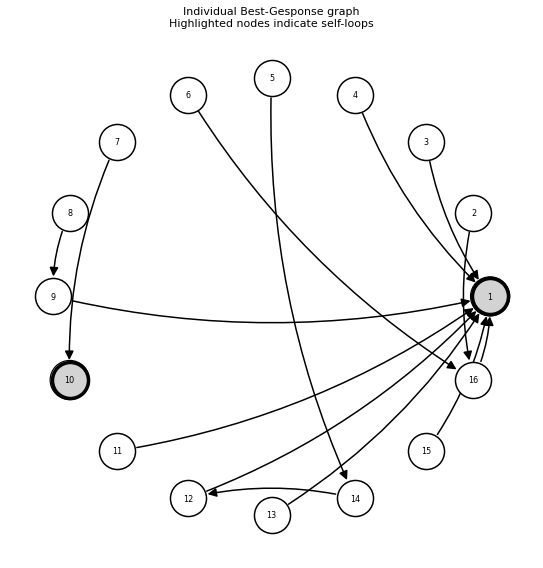

In [ ]:
all_relations = all_relations_PD

edges = IBR_edges_at_parameters(
    all_relations,
    t_value=1.1,
    r_value=0.9,
    p_value=0.2,
    s_value=0.0,
    delta_value=0.95,
    epsilon_value=0.2
)

show_best_response_graph(edges, strats=strats)

# Exercise 1

Print out "strats" and identify the indeces of some strategies of interest such as All-Defect, Grim Trigger, Win-Stay Lose-Shift, Tit-for-Tat and All-Cooperate.

# Exercise 2

Pick one of the three games and analyse the output of all_best_response_relations(strats). In particular, answer the following questions:

1. How many feasible best-response relations are found?
2. Which relations hold everywhere in the admissible domain?
3. Are there strategies that never appear as a best response?

# Exercise 3

Use the code above to plot the IBR graph for your choice of the parameters t, r, p, s, delta and epsilon. Make sure that your choice of parameters satisfy the conditions required for your choice of game. Then asnwer the following questions.

1. What are the possible symmetric Nash equilibria?
2. What are the possible asymmetric Nash equilibria?
3. Which equilibria correspond to known named strategies?
4. What are the conditions for the existence of the equilibria?


# Exercise 4

A collusive/cooperative strategy profile is one in which the agents spend most of their time in the $(C, C)$ state. Are any of the equilibria identified in Exercise 3 collusive/cooperative?

# Exercise 5

1. What are the basins of attraction (or probability of absorption) of the equilibria identified in Exercise 3?
2. What is the joint basin of attraction of the collusive/cooperative equilibria?
3. Is it more likely that the players will end up cooperating or defecting?

# Exercise 6

Repeat the above analysis for another choice of the parameters. Is there any notable change in your results? For example, do certain parameters dratically influence the probability of ending up in a collusive/cooperative equilibrium?